In [1]:
import os
from google.colab import drive
;
# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


# **denenecek tüm modeller :**
    
# base_models = {
    'ResNet50': ResNet50, sekme1 +
    'EfficientNetB0': EfficientNetB0, sekme2 +
    'VGG16': VGG16,
    'VGG19': VGG19,
    'InceptionV3': InceptionV3, sekem2+
    'DenseNet121': DenseNet121,
    'DenseNet169': DenseNet169,
    'DenseNet201': DenseNet201,
    'MobileNetV2': MobileNetV2,
    'NASNetMobile': NASNetMobile sekme1 +
}



# **'ResNet50': ResNet5**

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
94765736/94765736 [==============================] - 5s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5, Epochs: 14
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5, Epochs: 29
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 19
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.44999998807907104, Epochs: 11
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5, Epochs: 21
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 17
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.550000011920929, Epochs: 12
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.550000011920929, Epochs: 12
Model: ResNet50, Acti

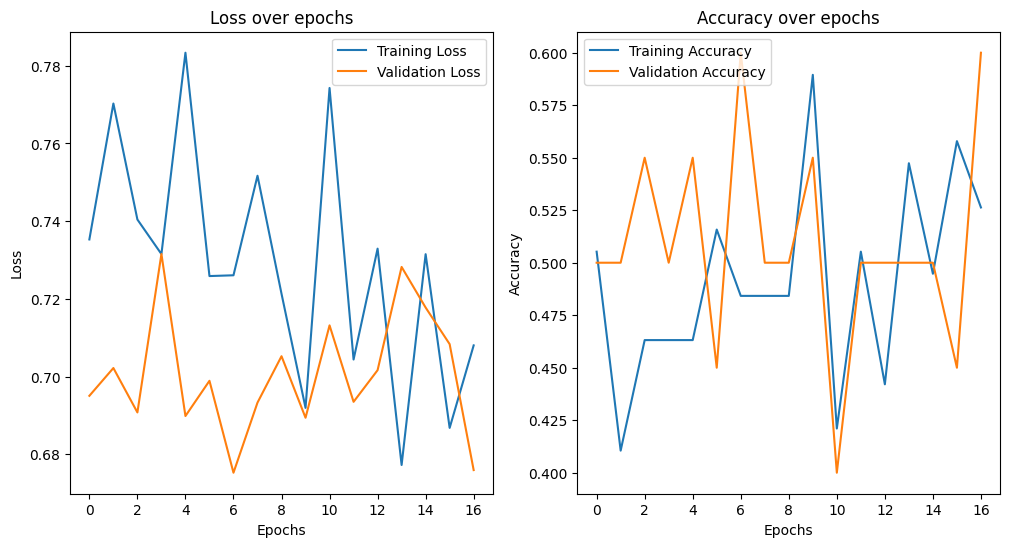

6/6 [==============================] - 2s 248ms/step
Weighted Precision: 0.7608695652173914
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.399108138238573
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.75
Macro Recall: 0.5416666666666666
Macro F1 Score: 0.41025641025641024
Precision (None): [0.5 1. ]
Recall (None): [1.         0.08333333]
F1 Score (None): [0.66666667 0.15384615]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-5, 1e-4, 1e-3]
epochs = 100  # Adjust based on early stopping

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsResNet50.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    val_loss = history.history['val_loss'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'val_loss': val_loss,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **NASNetMobile**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5, Epochs: 21
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 22
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5, Epochs: 21
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5, Epochs: 22
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.4375, Epochs: 31
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5625, Epochs: 23
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.4375, Epochs: 36
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy

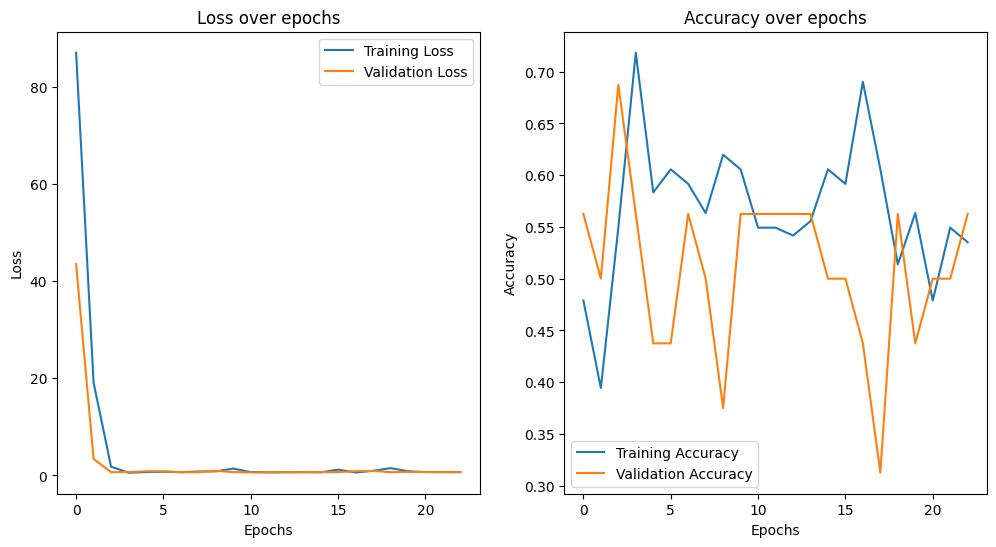

5/5 [==============================] - 5s 197ms/step
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.36651583710407243
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.2647058823529412
Macro Recall: 0.5
Macro F1 Score: 0.3461538461538462
Precision (None): [0.         0.52941176]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.69230769]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)



# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'NASNetMobile': NASNetMobile
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsNASNetMobile.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **MobileNetV2**

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
9406464/9406464 [==============================] - 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.6000000238418579, Epochs: 82
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.6499999761581421, Epochs: 102
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 51
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.6499999761581421, Epochs: 109
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 66
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 51
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.4000000059604645, Epochs: 66
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.649

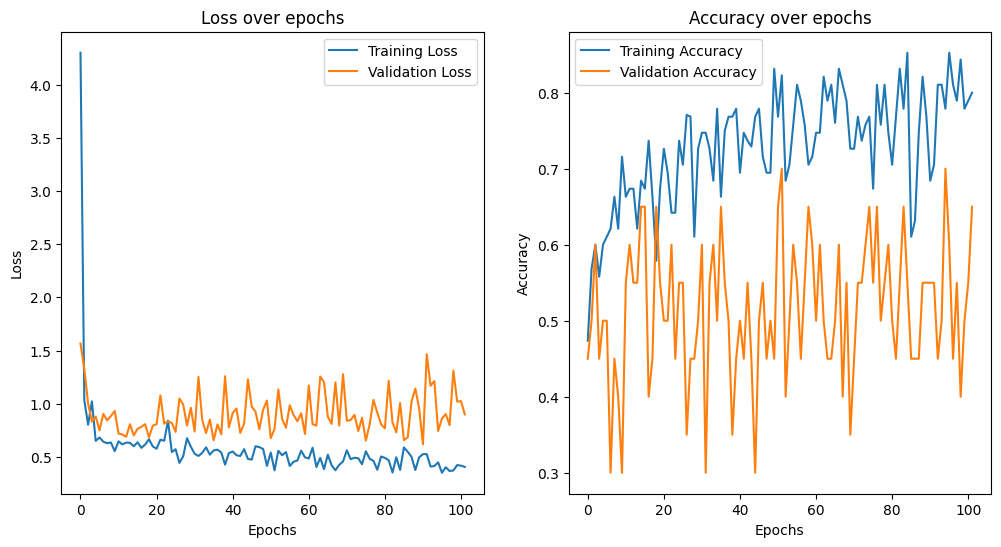

6/6 [==============================] - 2s 220ms/step
Weighted Precision: 0.2722117202268431
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.35776397515527947
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.2608695652173913
Macro Recall: 0.5
Macro F1 Score: 0.3428571428571428
Precision (None): [0.         0.52173913]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.68571429]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'MobileNetV2': MobileNetV2
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsMobileNetV2.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved parameters
best_model_name = best_params['model']
best_activation = best_params['activation']
best_dropout_rate = best_params['dropout_rate']
best_learning_rate = best_params['learning_rate']

base_model = base_models[best_model_name](weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_activation)(x)
x = Dropout(best_dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

best_model = Model(inputs=base_model.input, outputs=output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_learning_rate),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **'DenseNet201'**

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.3333333432674408, Epochs: 58
Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 1.0, Epochs: 68
Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.6666666865348816, Epochs: 60
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 1.0, Epochs: 54
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.6666666865348816, Epochs: 64
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.6666666865348816, Epochs: 68
Model: DenseNet201, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.6666666865348816, Epochs: 78
Model: DenseNet201, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.6666666865348816, 

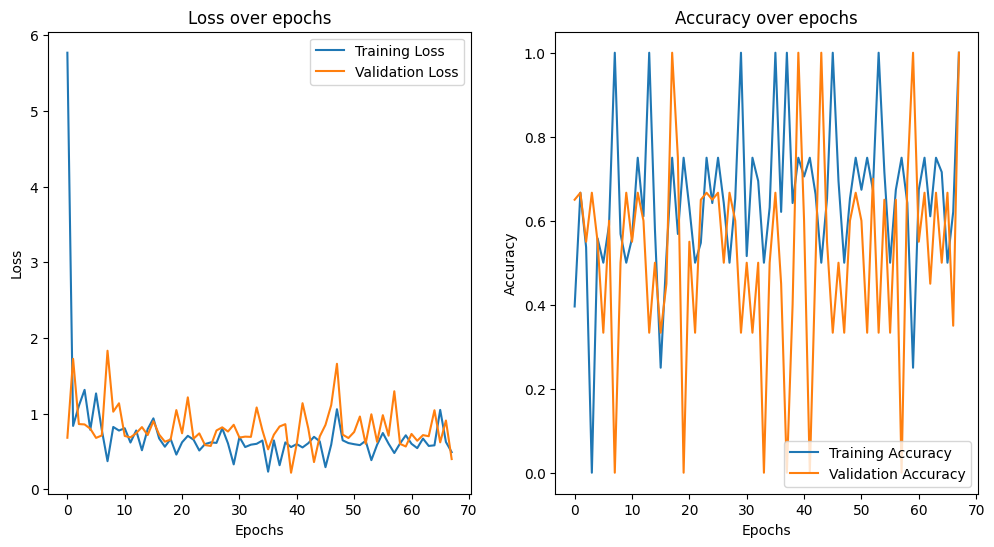

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 389 objects could not be loaded. Example error message for object <Conv2D name=stem_conv1, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(3, 3, 3, 32), Received: value.shape=(7, 7, 3, 64). Target variable: <KerasVariable shape=(3, 3, 3, 32), dtype=float32, path=stem_conv1/kernel>

List of objects that could not be loaded:
[<Conv2D name=stem_conv1, built=True>, <BatchNormalization name=stem_bn1, built=True>, <Conv2D name=reduction_conv_1_stem_1, built=True>, <BatchNormalization name=reduction_bn_1_stem_1, built=True>, <SeparableConv2D name=separable_conv_1_reduction_left1_stem_1, built=True>, <SeparableConv2D name=separable_conv_1_reduction_right1_stem_1, built=True>, <BatchNormalization name=separable_conv_1_bn_reduction_left1_stem_1, built=True>, <BatchNormalization name=separable_conv_1_bn_reduction_right1_stem_1, built=True>, <SeparableConv2D name=separable_conv_2_reducti

In [ ]:
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet201': DenseNet201
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsDenseNet201.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

if best_params:
    history = best_params['history']
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    # Recreate the best model using the saved output tensor
    base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=best_params['activation'])(x)
    x = Dropout(best_params['dropout_rate'])(x)
    best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

    best_model = Model(inputs=base_model.input, outputs=best_output)
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    # Load the best model weights
    best_model.load_weights('best_model.keras')

    predictions = best_model.predict(val_generator)
    y_true = val_generator.classes
    y_pred = (predictions > 0.5).astype(int)

    precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
    precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

    print("Weighted Precision:", precision_weighted)
    print("Weighted Recall:", recall_weighted)
    print("Weighted F1 Score:", f1_score_weighted)
    print("Micro Precision:", precision_micro)
    print("Micro Recall:", recall_micro)
    print("Micro F1 Score:", f1_score_micro)
    print("Macro Precision:", precision_macro)
    print("Macro Recall:", recall_macro)
    print("Macro F1 Score:", f1_score_macro)
    print("Precision (None):", precision_none)
    print("Recall (None):", recall_none)
    print("F1 Score (None):", f1_score_none)
else:
    print("No successful model training was found.")


# **'DenseNet169': DenseNet169**

In [ ]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
   'DenseNet169': DenseNet169
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsDenseNet169.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **DenseNet121**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
29084464/29084464 [==============================] - 0s 0us/step
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.4375, Epochs: 55
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.4375, Epochs: 57
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5625, Epochs: 57
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5625, Epochs: 52
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5625, Epochs: 66
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5, Epochs: 58
Model: DenseNet121, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5625, Epochs: 123
Model: DenseNet121, Activation

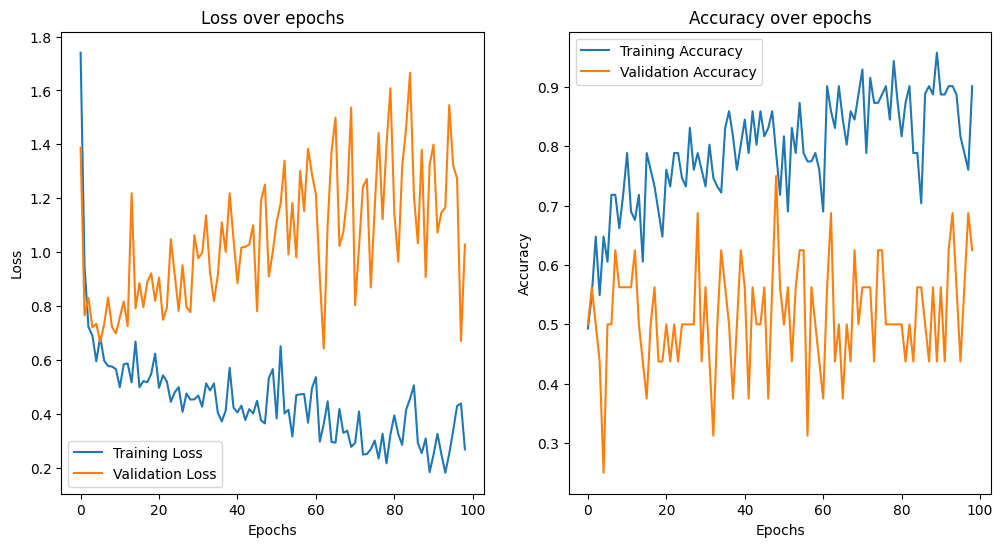

5/5 [==============================] - 3s 227ms/step
Weighted Precision: 0.22145328719723184
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.30117647058823527
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.23529411764705882
Macro Recall: 0.5
Macro F1 Score: 0.31999999999999995
Precision (None): [0.47058824 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64 0.  ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
   'DenseNet121': DenseNet121
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsDenseNet121.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
